In [123]:

# ── CELDA 1: IMPORTS Y CONEXIÓN 
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
import gspread
from google.oauth2.service_account import Credentials

# Estilo global
plt.rcParams.update({
    "figure.dpi": 130,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

COLORES_METODO = {
    "LinearRegression":        "#2E86AB",
    "Ridge":                   "#A23B72",
    "RandomForestRegressor":   "#F18F01",
    "GradientBoostingRegressor": "#4CAF50",
}

COLORES_ARCHIVO = {
    "df_semanal.csv":  "#264653",
    "df_semanal_1.csv":"#2A9D8F",
    "df_semanal_2.csv":"#E9C46A",
    "df_semanal_3.csv":"#F4A261",
    "df_semanal_4.csv":"#E76F51",
}

LAGS_LABEL = {
    "df_semanal.csv":  "0 lags",
    "df_semanal_1.csv":"1 lag",
    "df_semanal_2.csv":"2 lags",
    "df_semanal_3.csv":"3 lags",
    "df_semanal_4.csv":"4 lags",
}


In [124]:

# LEER GOOGLE SHEETS 
SCOPES = [
    "https://www.googleapis.com/auth/spreadsheets",
    "https://www.googleapis.com/auth/drive",
]
SERVICE_ACCOUNT_FILE = "credenciales_google.json"
SHEET_URL = "https://docs.google.com/spreadsheets/d/17T0L6gza7vzD1vFh6OG2j3qOmlKCDRtFFu5HNma1Agk/edit?gid=836870544#gid=836870544"

def conectar_y_leer():
    creds = Credentials.from_service_account_file(SERVICE_ACCOUNT_FILE, scopes=SCOPES)
    client = gspread.authorize(creds)
    ws = client.open_by_url(SHEET_URL).get_worksheet(0)

    values = ws.get_all_values()   
    header = values[0]
    rows = values[1:]

    df = pd.DataFrame(rows, columns=header)
    return df

df_raw = conectar_y_leer()
print(f"Filas leídas: {len(df_raw)}")
print(df_raw.columns.tolist())



Filas leídas: 1160
['Archivo', 'Método', 'Target', 'FechaIni', 'FechaFin', 'RMSE', 'RMSE_baseline', 'RMSE_zeros', 'MAE', 'MAE_baseline', 'MAE_zeros', 'Estado', 'Alpha', 'n_estimators', 'max_depth', 'min_samples_leaf', 'max_features', 'learning_rate', 'subsample', 'FechaPredIni', 'FechaPredFin', 'FechaTrainIni', 'FechaTrainFin', 'ValorReal']


In [125]:
def parse_num(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()
    if s == "":
        return np.nan

    s = s.replace("\xa0", "").replace(" ", "").replace("%", "")

    # Caso tipo 1.234,56
    if "," in s and "." in s:
        if s.rfind(",") > s.rfind("."):
            s = s.replace(".", "").replace(",", ".")
        else:
            # Caso tipo 1,234.56
            s = s.replace(",", "")
    elif "," in s:
        # Caso tipo 0,00301
        s = s.replace(",", ".")

    return pd.to_numeric(s, errors="coerce")

In [126]:
def limpiar(df):
    df = df.copy()

    df = df[df["Estado"].astype(str).str.upper() == "DONE"].copy()

    num_cols = ["RMSE", "RMSE_baseline", "RMSE_zeros",
                "MAE", "MAE_baseline", "MAE_zeros"]

    for c in num_cols:
        df[c] = df[c].apply(parse_num)

    df["ETF"] = df["Target"].astype(str).str.replace("target_", "", regex=False)
    df["Lags"] = df["Archivo"].map(LAGS_LABEL).fillna("?")

    df["Mejora_vs_baseline"] = (
        (df["RMSE_baseline"] - df["RMSE"]) / df["RMSE_baseline"] * 100
    ).round(2)

    df["Mejora_vs_zeros"] = (
        (df["RMSE_zeros"] - df["RMSE"]) / df["RMSE_zeros"] * 100
    ).round(2)

    df["Bate_baseline"] = df["RMSE"] < df["RMSE_baseline"]
    df["Bate_zeros"] = df["RMSE"] < df["RMSE_zeros"]

    return df

In [127]:
df = limpiar(df_raw)


In [128]:

# TABLAS RESUMEN
# TABLA RESUMEN GENERAL por Método y Archivo
print("\n" + "="*70)
print("TABLA 1 — RMSE medio por Método y Archivo (número de lags)")
print("="*70)

tabla1 = df.groupby(["Archivo","Método"])[["RMSE","RMSE_baseline","RMSE_zeros"]].mean().round(5)
tabla1["Mejora_vs_baseline(%)"] = (
    (tabla1["RMSE_baseline"] - tabla1["RMSE"]) / tabla1["RMSE_baseline"] * 100
).round(2)
tabla1["Mejora_vs_zeros(%)"] = (
    (tabla1["RMSE_zeros"] - tabla1["RMSE"]) / tabla1["RMSE_zeros"] * 100
).round(2)
print(tabla1.to_string())



TABLA 1 — RMSE medio por Método y Archivo (número de lags)
                                               RMSE  RMSE_baseline  RMSE_zeros  Mejora_vs_baseline(%)  Mejora_vs_zeros(%)
Archivo          Método                                                                                                  
df_semanal.csv   GradientBoostingRegressor  0.00494        0.00717     0.00494                  31.10                0.00
                 LinearRegression           0.00784        0.00717     0.00494                  -9.34              -58.70
                 RandomForestRegressor      0.00491        0.00717     0.00494                  31.52                0.61
                 Ridge                      0.00490        0.00717     0.00494                  31.66                0.81
df_semanal_1.csv GradientBoostingRegressor  0.00491        0.00717     0.00494                  31.52                0.61
                 LinearRegression           0.01437        0.00717     0.00494        

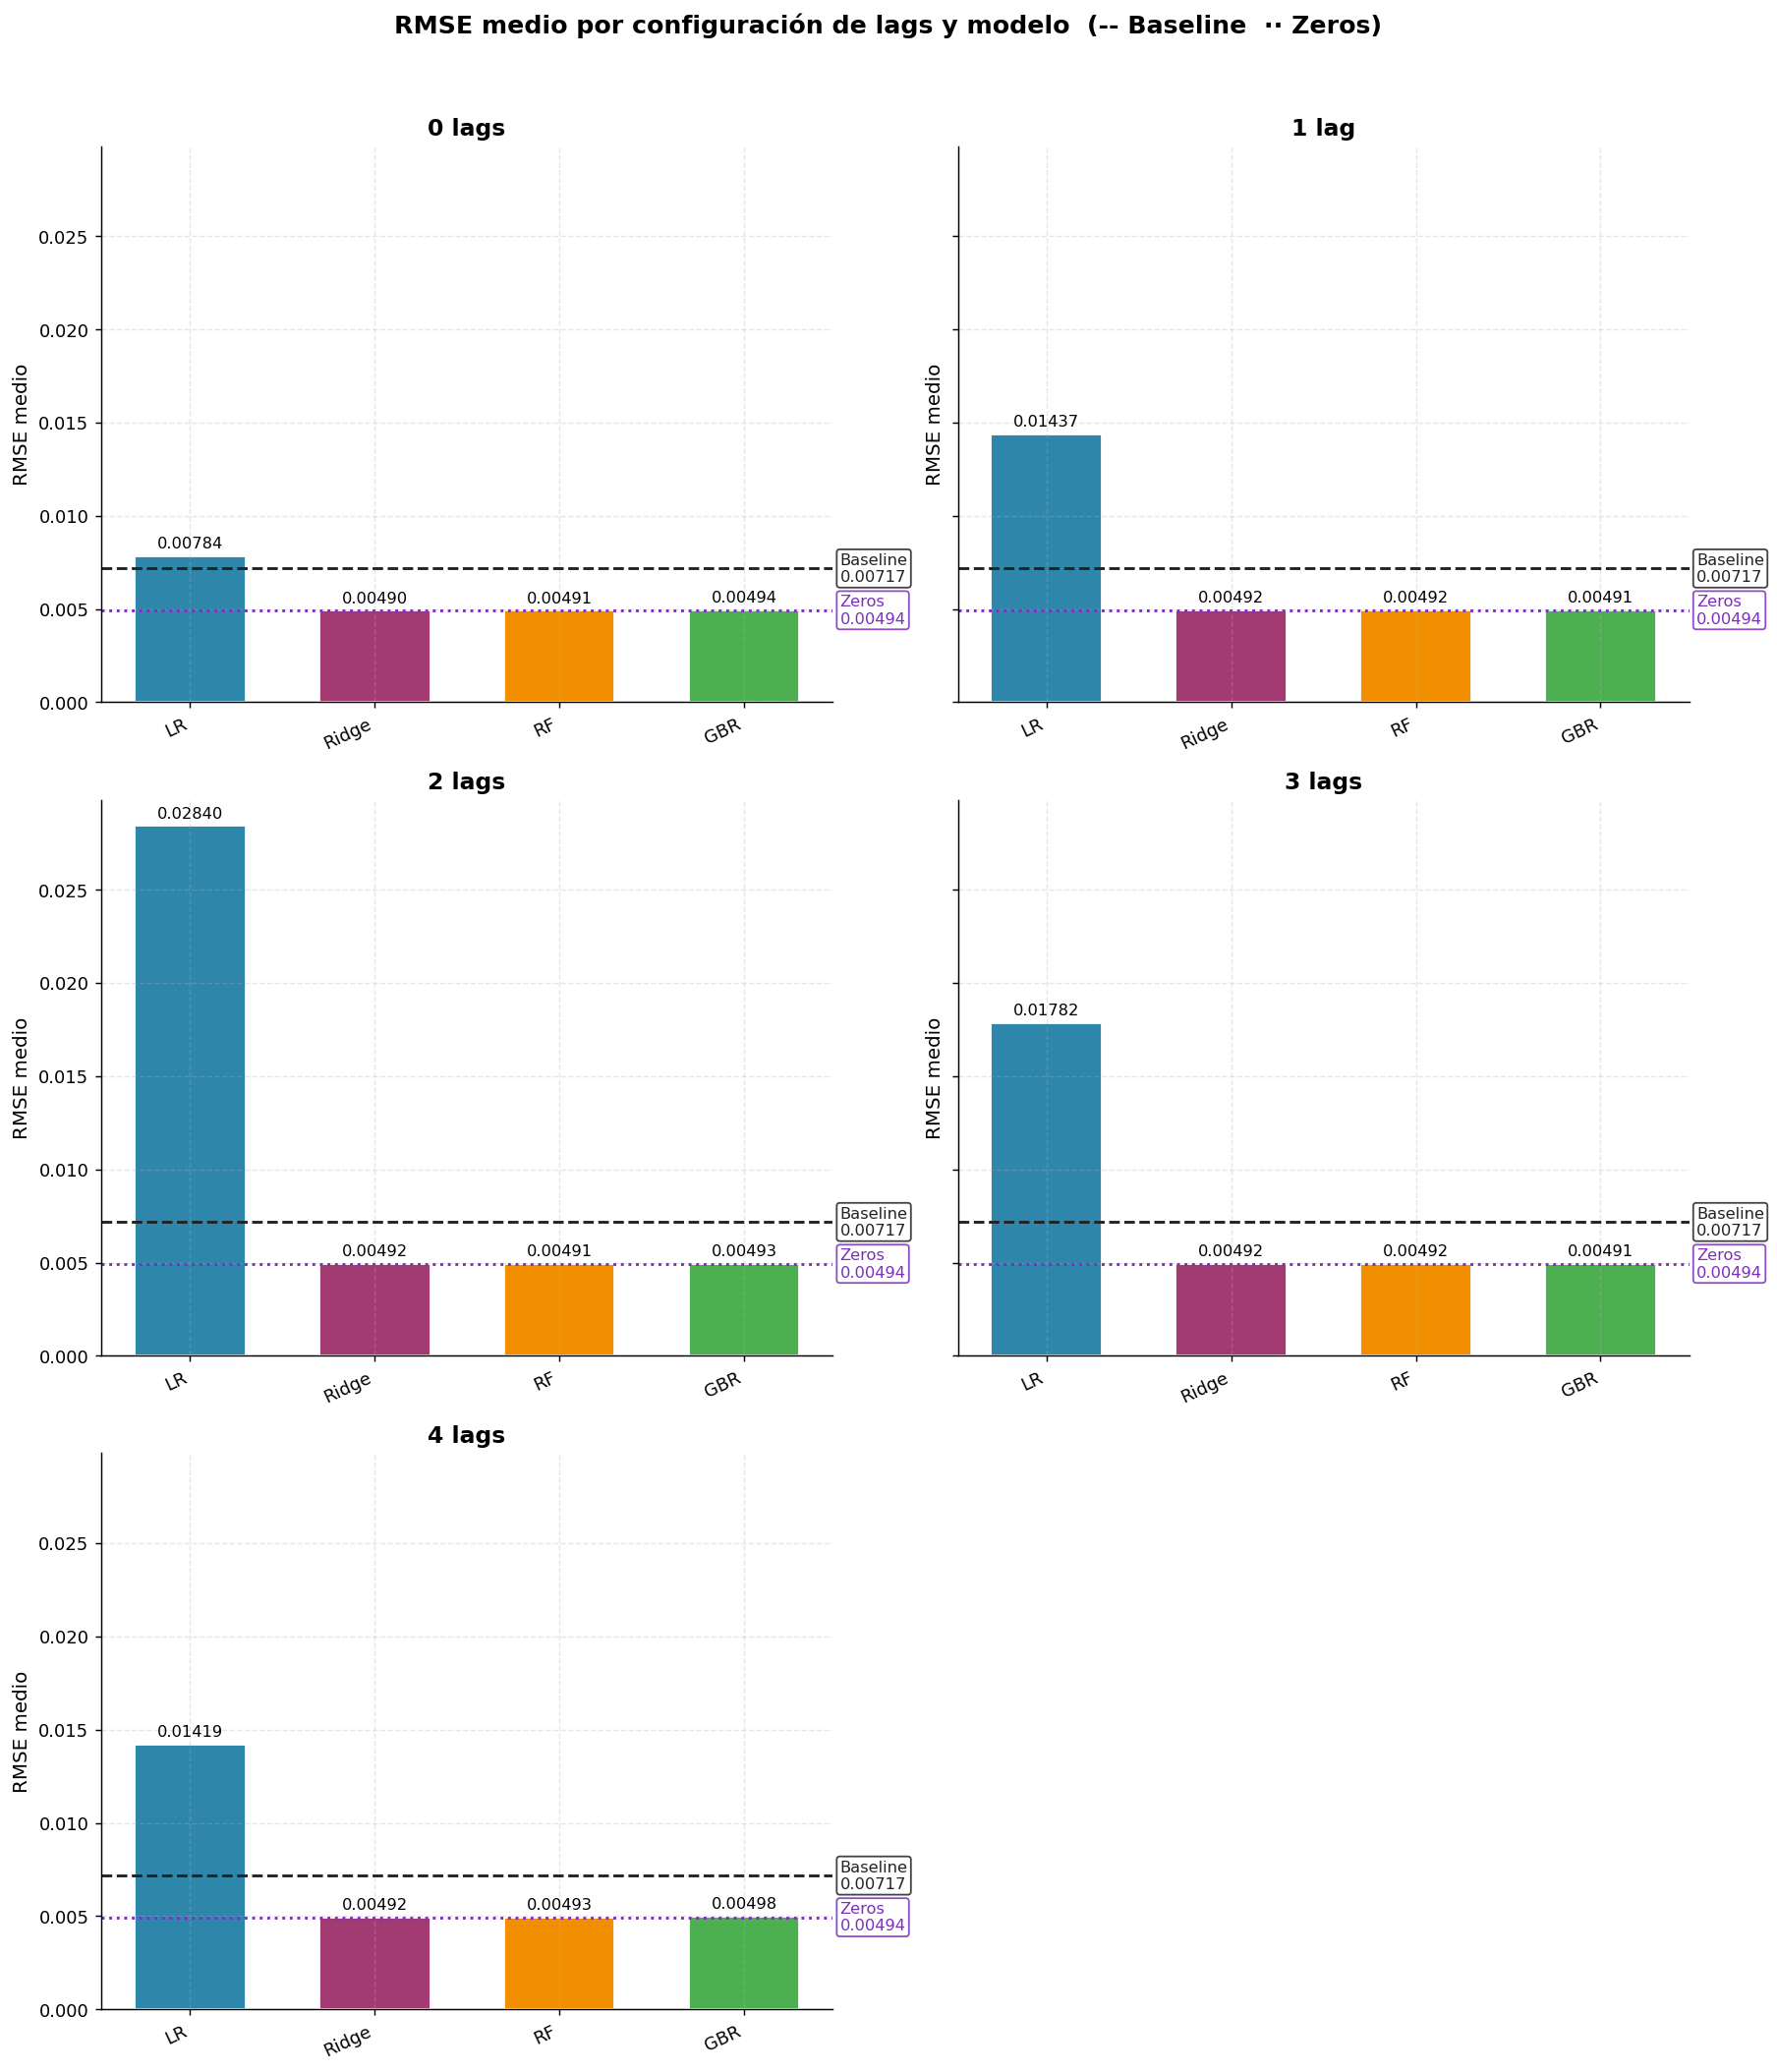

In [ ]:
import math
import matplotlib.pyplot as plt

# GRAFICO TABLA 1 — RMSE por Archivo y Método (más grande y en varios subplots)
archivos_orden = [
    "df_semanal.csv", "df_semanal_1.csv", "df_semanal_2.csv",
    "df_semanal_3.csv", "df_semanal_4.csv"
]

archivos_pres = [a for a in archivos_orden if a in df["Archivo"].unique()]
metodos_ord   = list(COLORES_METODO.keys())
n             = len(archivos_pres)

# ---- CAMBIO IMPORTANTE: varios subplots en rejilla ----
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5.5 * nrows), sharey=True)
axes = axes.flatten()  # para recorrerlos fácil aunque haya varias filas

for ax, archivo in zip(axes, archivos_pres):
    sub      = df[df["Archivo"] == archivo]
    por_met  = sub.groupby("Método")["RMSE"].mean().reindex(metodos_ord).dropna()
    baseline = sub["RMSE_baseline"].mean()
    zeros    = sub["RMSE_zeros"].mean()

    x       = range(len(por_met))
    colores = [COLORES_METODO.get(m, "#888") for m in por_met.index]

    bars = ax.bar(x, por_met.values, color=colores, edgecolor="white", width=0.6)
    ax.bar_label(bars, fmt="%.5f", fontsize=9, padding=3)

    ax.axhline(baseline, color="#222", linestyle="--", linewidth=1.6)
    ax.axhline(zeros,    color="#7B2FBE", linestyle=":", linewidth=1.6)

    ax.annotate(
        f"Baseline\n{baseline:.5f}",
        xy=(1.01, baseline), xycoords=("axes fraction", "data"),
        fontsize=9, color="#222", va="center",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#222", alpha=0.85)
    )

    ax.annotate(
        f"Zeros\n{zeros:.5f}",
        xy=(1.01, zeros), xycoords=("axes fraction", "data"),
        fontsize=9, color="#7B2FBE", va="center",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#7B2FBE", alpha=0.85)
    )

    etiq = [
        m.replace("GradientBoostingRegressor", "GBR")
         .replace("RandomForestRegressor", "RF")
         .replace("LinearRegression", "LR")
        for m in por_met.index
    ]

    ax.set_xticks(list(x))
    ax.set_xticklabels(etiq, rotation=25, ha="right", fontsize=10)
    ax.set_title(LAGS_LABEL.get(archivo, archivo), fontsize=13, fontweight="bold")
    ax.set_ylabel("RMSE medio", fontsize=11)

# ocultar ejes vacíos si sobran
for j in range(len(archivos_pres), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "RMSE medio por configuración de lags y modelo  (-- Baseline  ·· Zeros)",
    fontsize=14, fontweight="bold", y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig("G02_rmse_por_archivo_metodo.png", dpi=150, bbox_inches="tight")
plt.show()

In [130]:

# CONFIGURACIÓN ÚNICA

ETF_ELIMINADOS = {"BIL", "EWY", "GLD", "IAU", "SHY"}

GRUPOS_ETF = {
    "Mercado estadounidense (Core US)": [
        "SPY","IVV","VOO","QQQ","VTI","ITOT","DIA","IWM","IJR","MDY",
    ],
    "Factores y estilos": [
        "VUG","IWF","VTV","IWD","SCHD","VIG","DVY","MTUM","QUAL","USMV","VLUE",
    ],
    "Sectores económicos": [
        "XLK","XLF","XLV","XLY","XLP","XLE","XLI","XLU","XLB","XLRE",
    ],
    "Mercados internacionales": [
        "VEA","IEFA","VWO","IEMG","EEM","EFA",
        "EWJ","EWG","EWU","EWQ","INDA","EWZ","FXI","MCHI","EWT",
    ],
    "Renta fija": [
        "BND","AGG","IEF","TLT","LQD","HYG","JNK","TIP",
    ],
    "Materias primas y activos reales": [
        "SLV","USO","DBC","VNQ",
    ],
}

ORDEN_GRUPOS = list(GRUPOS_ETF.keys())
etf_to_grupo = {etf: g for g, etfs in GRUPOS_ETF.items() for etf in etfs}



# FUNCIONES AUXILIARES
#

def pct_mejora(base, modelo):
    if pd.isna(base) or pd.isna(modelo) or base == 0:
        return np.nan
    return (base - modelo) / base * 100


def preparar_base(df):
    out = df[~df["ETF"].isin(ETF_ELIMINADOS)].copy()

    for c in ["RMSE","RMSE_baseline","RMSE_zeros","MAE","MAE_baseline","MAE_zeros"]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")

    out = out.dropna(subset=["ETF","Archivo","Método","RMSE","MAE"]).copy()
    return out


def enriquecer_df(out):
    out = out.copy()

    out["Grupo"] = out["ETF"].map(etf_to_grupo).fillna("Sin grupo")
    out["Lags"] = out["Archivo"].map(LAGS_LABEL).fillna(out["Archivo"])
    out["Método_c"] = out["Método"].replace({
        "GradientBoostingRegressor": "GBR",
        "RandomForestRegressor": "RF",
        "LinearRegression": "LR",
    })

    out["Mej_RMSE_baseline(%)"] = out.apply(lambda r: pct_mejora(r["RMSE_baseline"], r["RMSE"]), axis=1)
    out["Mej_RMSE_zeros(%)"]    = out.apply(lambda r: pct_mejora(r["RMSE_zeros"], r["RMSE"]), axis=1)
    out["Mej_MAE_baseline(%)"]  = out.apply(lambda r: pct_mejora(r["MAE_baseline"], r["MAE"]), axis=1)
    out["Mej_MAE_zeros(%)"]     = out.apply(lambda r: pct_mejora(r["MAE_zeros"], r["MAE"]), axis=1)

    out["Bate_zeros"] = out["RMSE"] < out["RMSE_zeros"]

    out["_ord"] = out["Grupo"].map({g: i for i, g in enumerate(ORDEN_GRUPOS)}).fillna(999)
    out = out.sort_values(["_ord", "RMSE", "MAE", "ETF"]).drop(columns="_ord")

    return out


def resumen_consistente(sub):
    rmse_m   = sub["RMSE"].mean()
    mae_m    = sub["MAE"].mean()
    rmse_b_m = sub["RMSE_baseline"].mean()
    rmse_z_m = sub["RMSE_zeros"].mean()
    mae_b_m  = sub["MAE_baseline"].mean()
    mae_z_m  = sub["MAE_zeros"].mean()

    return {
        "RMSE medio": rmse_m,
        "MAE medio": mae_m,
        "Mejora RMSE baseline": pct_mejora(rmse_b_m, rmse_m),
        "Mejora RMSE zeros": pct_mejora(rmse_z_m, rmse_m),
        "Mejora MAE baseline": pct_mejora(mae_b_m, mae_m),
        "Mejora MAE zeros": pct_mejora(mae_z_m, mae_m),
    }


def imprimir_tabla_por_grupos(df_in, titulo):
    dfx = enriquecer_df(df_in)
    print("\n")
    print(titulo)
    print("="*120)

    cols = [
        "Lags", "Método_c", "RMSE", "MAE",
        "Mej_RMSE_baseline(%)", "Mej_RMSE_zeros(%)",
        "Mej_MAE_baseline(%)", "Mej_MAE_zeros(%)"
    ]

    ren = {
        "Método_c": "Método",
        "Mej_RMSE_baseline(%)": "Mej.RMSE_base(%)",
        "Mej_RMSE_zeros(%)":    "Mej.RMSE_zeros(%)",
        "Mej_MAE_baseline(%)":  "Mej.MAE_base(%)",
        "Mej_MAE_zeros(%)":     "Mej.MAE_zeros(%)",
    }

    for grupo in ORDEN_GRUPOS + ["Sin grupo"]:
        sub = dfx[dfx["Grupo"] == grupo].copy()
        if sub.empty:
            continue

        print(f"\n{grupo.upper()} ({len(sub)} ETFs)")

        tabla = sub.set_index("ETF")[cols].rename(columns=ren)

        for c in ["RMSE", "MAE"]:
            tabla[c] = tabla[c].map(lambda x: f"{x:.5f}" if pd.notnull(x) else "")

        for c in ["Mej.RMSE_base(%)", "Mej.RMSE_zeros(%)", "Mej.MAE_base(%)", "Mej.MAE_zeros(%)"]:
            tabla[c] = tabla[c].map(lambda x: f"{x:.2f}%" if pd.notnull(x) else "")

        print(tabla.to_string())

        res = resumen_consistente(sub)
        metodo_dom = sub["Método_c"].value_counts()
        lags_dom = sub["Lags"].value_counts()

        print("\n  Resumen del grupo:")
        print(f"  → RMSE medio          : {res['RMSE medio']:.5f}")
        print(f"  → MAE medio           : {res['MAE medio']:.5f}")
        print(f"  → Mejora RMSE baseline: {res['Mejora RMSE baseline']:.2f}%")
        print(f"  → Mejora RMSE zeros   : {res['Mejora RMSE zeros']:.2f}%")
        print(f"  → Mejora MAE baseline : {res['Mejora MAE baseline']:.2f}%")
        print(f"  → Mejora MAE zeros    : {res['Mejora MAE zeros']:.2f}%")
        print(f"  → ETFs que baten zeros: {int(sub['Bate_zeros'].sum())}/{len(sub)}")
        print(f"  → Modelo dominante    : {metodo_dom.index[0]} ({metodo_dom.iloc[0]} ETFs)")
        print(f"  → Lags dominante      : {lags_dom.index[0]} ({lags_dom.iloc[0]} ETFs)")
        if len(lags_dom) > 1:
            print("  → Distribución lags   : " + ", ".join(f"{l}: {n}" for l, n in lags_dom.items()))

        print("\n" + "-"*100)
        print("\n")

    

def seleccionar_modelo_global(df_base):
    tabla1_sel = (
        df_base
        .groupby(["Archivo", "Método"], as_index=False)
        .agg(
            RMSE=("RMSE", "mean"),
            MAE=("MAE", "mean"),
            RMSE_baseline=("RMSE_baseline", "mean"),
            RMSE_zeros=("RMSE_zeros", "mean"),
            MAE_baseline=("MAE_baseline", "mean"),
            MAE_zeros=("MAE_zeros", "mean"),
        )
    )

    tabla1_sel["Mejora_vs_baseline(%)"] = tabla1_sel.apply(
        lambda r: pct_mejora(r["RMSE_baseline"], r["RMSE"]), axis=1
    ).round(2)

    tabla1_sel["Mejora_vs_zeros(%)"] = tabla1_sel.apply(
        lambda r: pct_mejora(r["RMSE_zeros"], r["RMSE"]), axis=1
    ).round(2)

    fila = tabla1_sel.sort_values(["RMSE", "MAE", "Archivo", "Método"]).iloc[0]
    return tabla1_sel, fila




df_base = preparar_base(df)

In [131]:
tabla1_sel, fila_ganadora = seleccionar_modelo_global(df_base)

archivo_ganador = fila_ganadora["Archivo"]
metodo_ganador = fila_ganadora["Método"]

print("MENOR RMSE POR ARCHIVO Y MÉTODO")
print(f"Archivo ganador : {archivo_ganador} ({LAGS_LABEL.get(archivo_ganador, archivo_ganador)})")
print(f"Método ganador  : {metodo_ganador}")
print(f"RMSE medio      : {fila_ganadora['RMSE']:.5f}")
print(f"MAE medio       : {fila_ganadora['MAE']:.5f}")
print(f"Mejora baseline : {fila_ganadora['Mejora_vs_baseline(%)']:.2f}%")
print(f"Mejora zeros    : {fila_ganadora['Mejora_vs_zeros(%)']:.2f}%")

df_sel = df_base[
    (df_base["Archivo"] == archivo_ganador) &
    (df_base["Método"] == metodo_ganador)
].copy()

df_sel = (
    df_sel
    .sort_values(["ETF", "RMSE", "MAE"])
    .drop_duplicates(subset=["ETF"], keep="first")
)

imprimir_tabla_por_grupos(
    df_sel,
    "Resultados por ETF del modelo global ganador, agrupados por grupo"
)

MENOR RMSE POR ARCHIVO Y MÉTODO
Archivo ganador : df_semanal.csv (0 lags)
Método ganador  : Ridge
RMSE medio      : 0.00490
MAE medio       : 0.00365
Mejora baseline : 31.67%
Mejora zeros    : 0.66%


Resultados por ETF del modelo global ganador, agrupados por grupo

MERCADO ESTADOUNIDENSE (CORE US) (10 ETFs)
        Lags Método     RMSE      MAE Mej.RMSE_base(%) Mej.RMSE_zeros(%) Mej.MAE_base(%) Mej.MAE_zeros(%)
ETF                                                                                                      
DIA   0 lags  Ridge  0.00440  0.00342           35.58%             1.57%          34.61%            2.01%
VOO   0 lags  Ridge  0.00455  0.00338           36.89%             2.36%          35.74%            2.31%
SPY   0 lags  Ridge  0.00458  0.00338           37.09%             2.35%          35.86%            2.59%
IVV   0 lags  Ridge  0.00459  0.00339           37.30%             2.34%          35.92%            2.59%
VTI   0 lags  Ridge  0.00468  0.00347           36.15

In [132]:
df_mejor = (
    df_base
    .sort_values(["ETF", "RMSE", "MAE", "Archivo", "Método"])
    .drop_duplicates(subset=["ETF"], keep="first")
    .copy()
)

imprimir_tabla_por_grupos(
    df_mejor,
    "DE CADA ETF SELECCIONAMOS SU MEJOR MODELO Y ARCHIVO, agrupados por grupo"
)



DE CADA ETF SELECCIONAMOS SU MEJOR MODELO Y ARCHIVO, agrupados por grupo

MERCADO ESTADOUNIDENSE (CORE US) (10 ETFs)
        Lags Método     RMSE      MAE Mej.RMSE_base(%) Mej.RMSE_zeros(%) Mej.MAE_base(%) Mej.MAE_zeros(%)
ETF                                                                                                      
SPY   4 lags    GBR  0.00434  0.00324           40.38%             7.46%          38.52%            6.63%
DIA   2 lags    GBR  0.00434  0.00338           36.46%             2.91%          35.37%            3.15%
VOO   4 lags    GBR  0.00451  0.00353           37.45%             3.22%          32.89%           -2.02%
IVV   4 lags    GBR  0.00453  0.00342           38.11%             3.62%          35.35%            1.72%
ITOT  0 lags    GBR  0.00459  0.00348           37.55%             4.18%          35.20%            1.97%
VTI   0 lags    GBR  0.00464  0.00359           36.70%             2.93%          33.02%           -1.70%
MDY    1 lag     RF  0.00515  0.0

In [133]:
# TABLA — % de ETFs que baten cada benchmark . 
# De todos los experimentos realizados con cada método, en qué porcentaje de veces ese método consiguió un error menor que los modelos de referencia.

print(" % de ETFs que baten cada benchmark por Método")


tabla = df_base.groupby("Método").agg(
    Pct_bate_baseline=("Bate_baseline", lambda x: round(x.mean()*100, 1)),
    Pct_bate_zeros=("Bate_zeros",    lambda x: round(x.mean()*100, 1)),
    N_experimentos=("RMSE", "count")
).sort_values("Pct_bate_baseline", ascending=False)
print(tabla.to_string())


 % de ETFs que baten cada benchmark por Método
                           Pct_bate_baseline  Pct_bate_zeros  N_experimentos
Método                                                                      
GradientBoostingRegressor              100.0            52.1             290
RandomForestRegressor                  100.0            63.4             290
Ridge                                  100.0            62.4             290
LinearRegression                         4.1             0.0             290


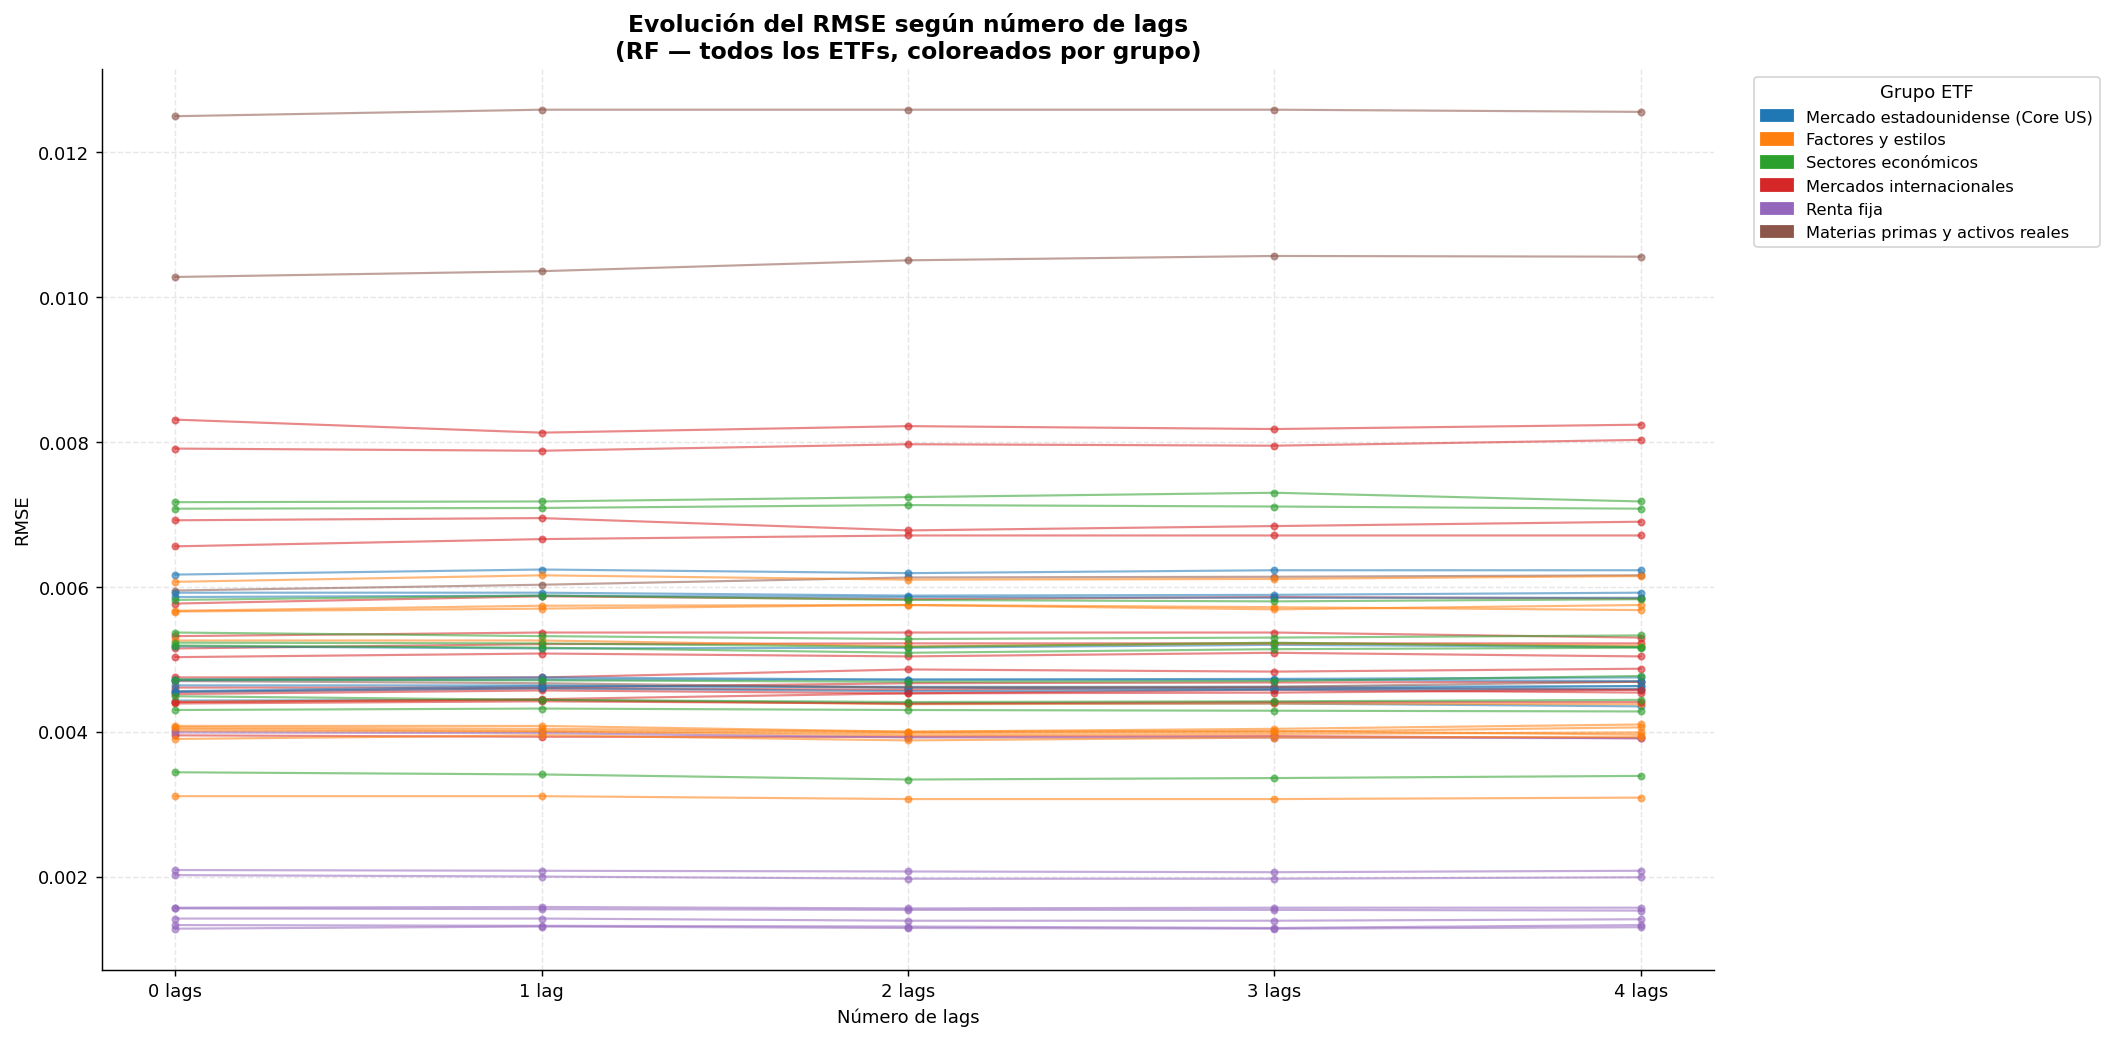

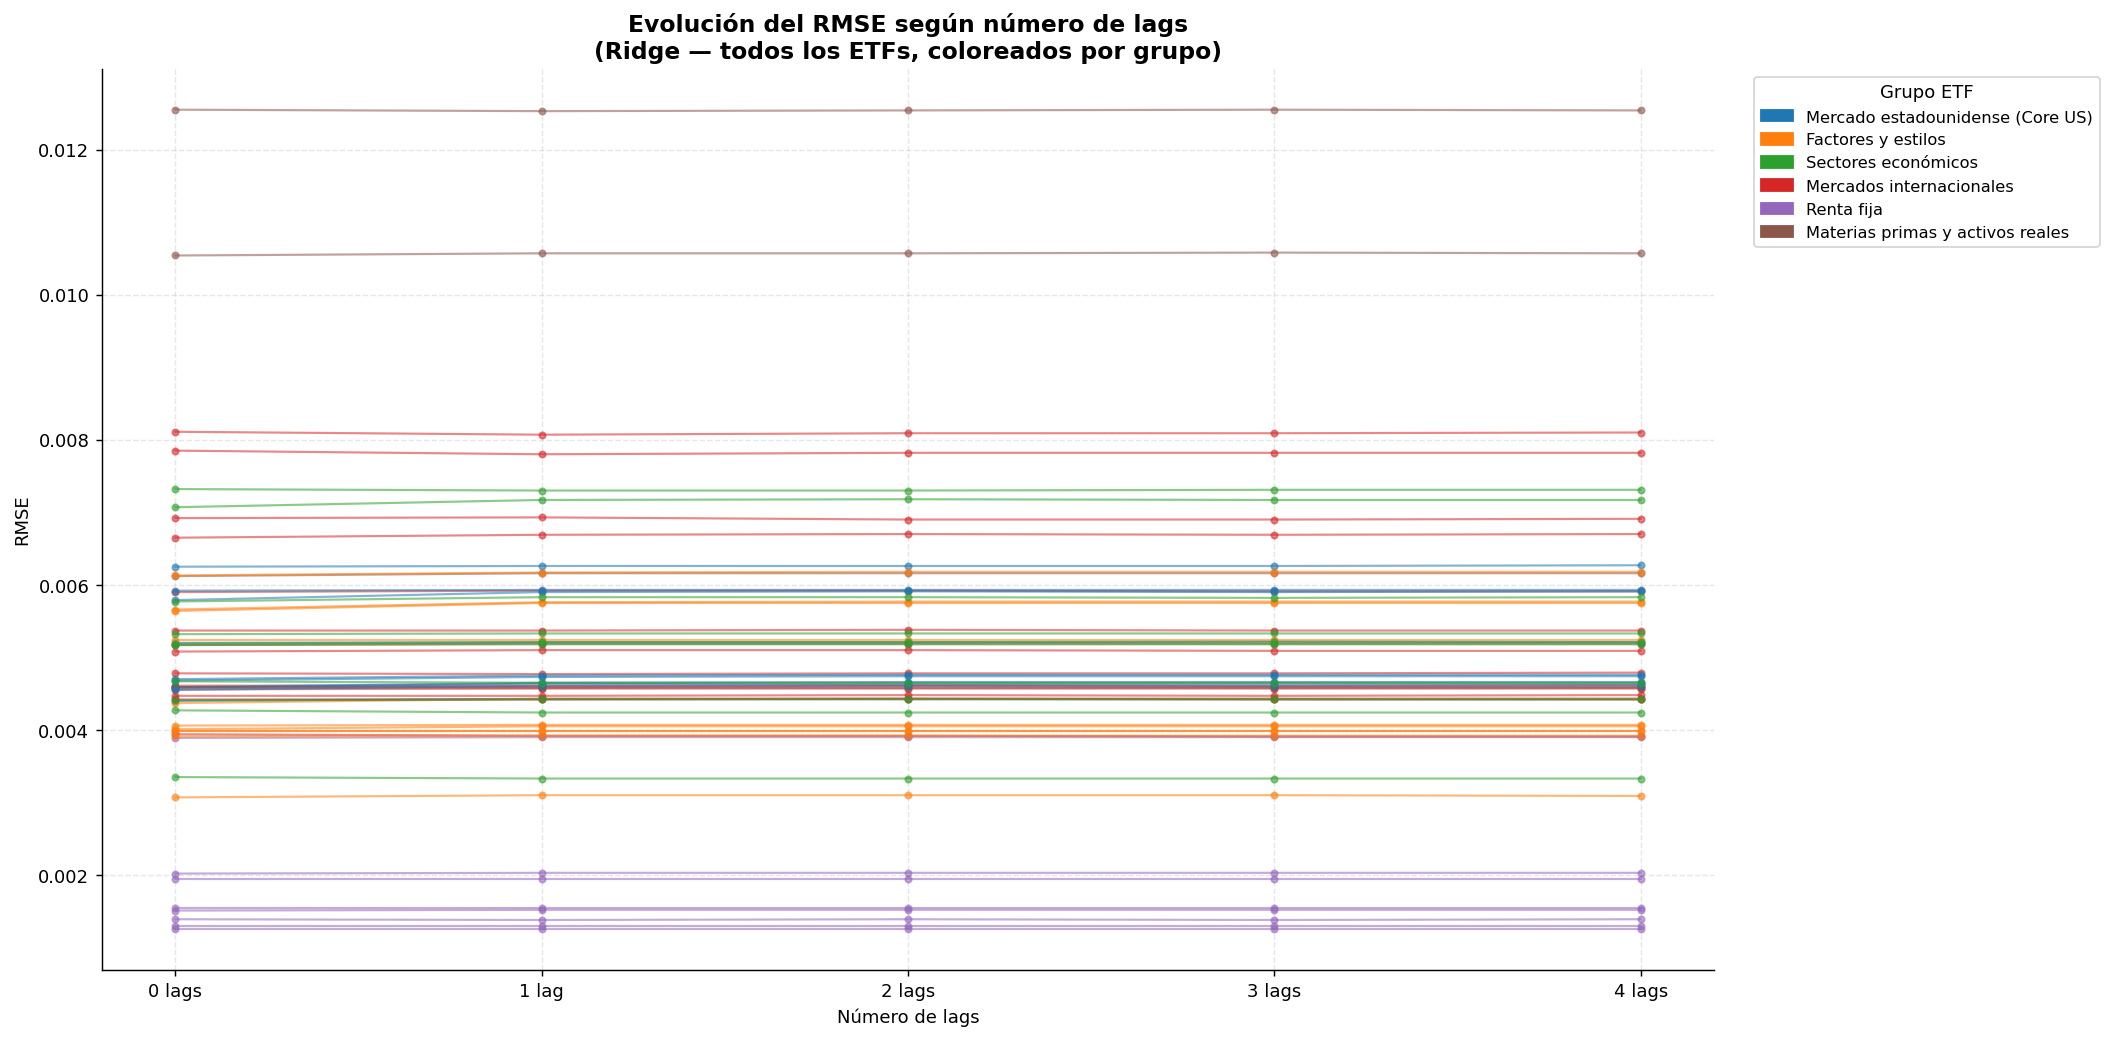

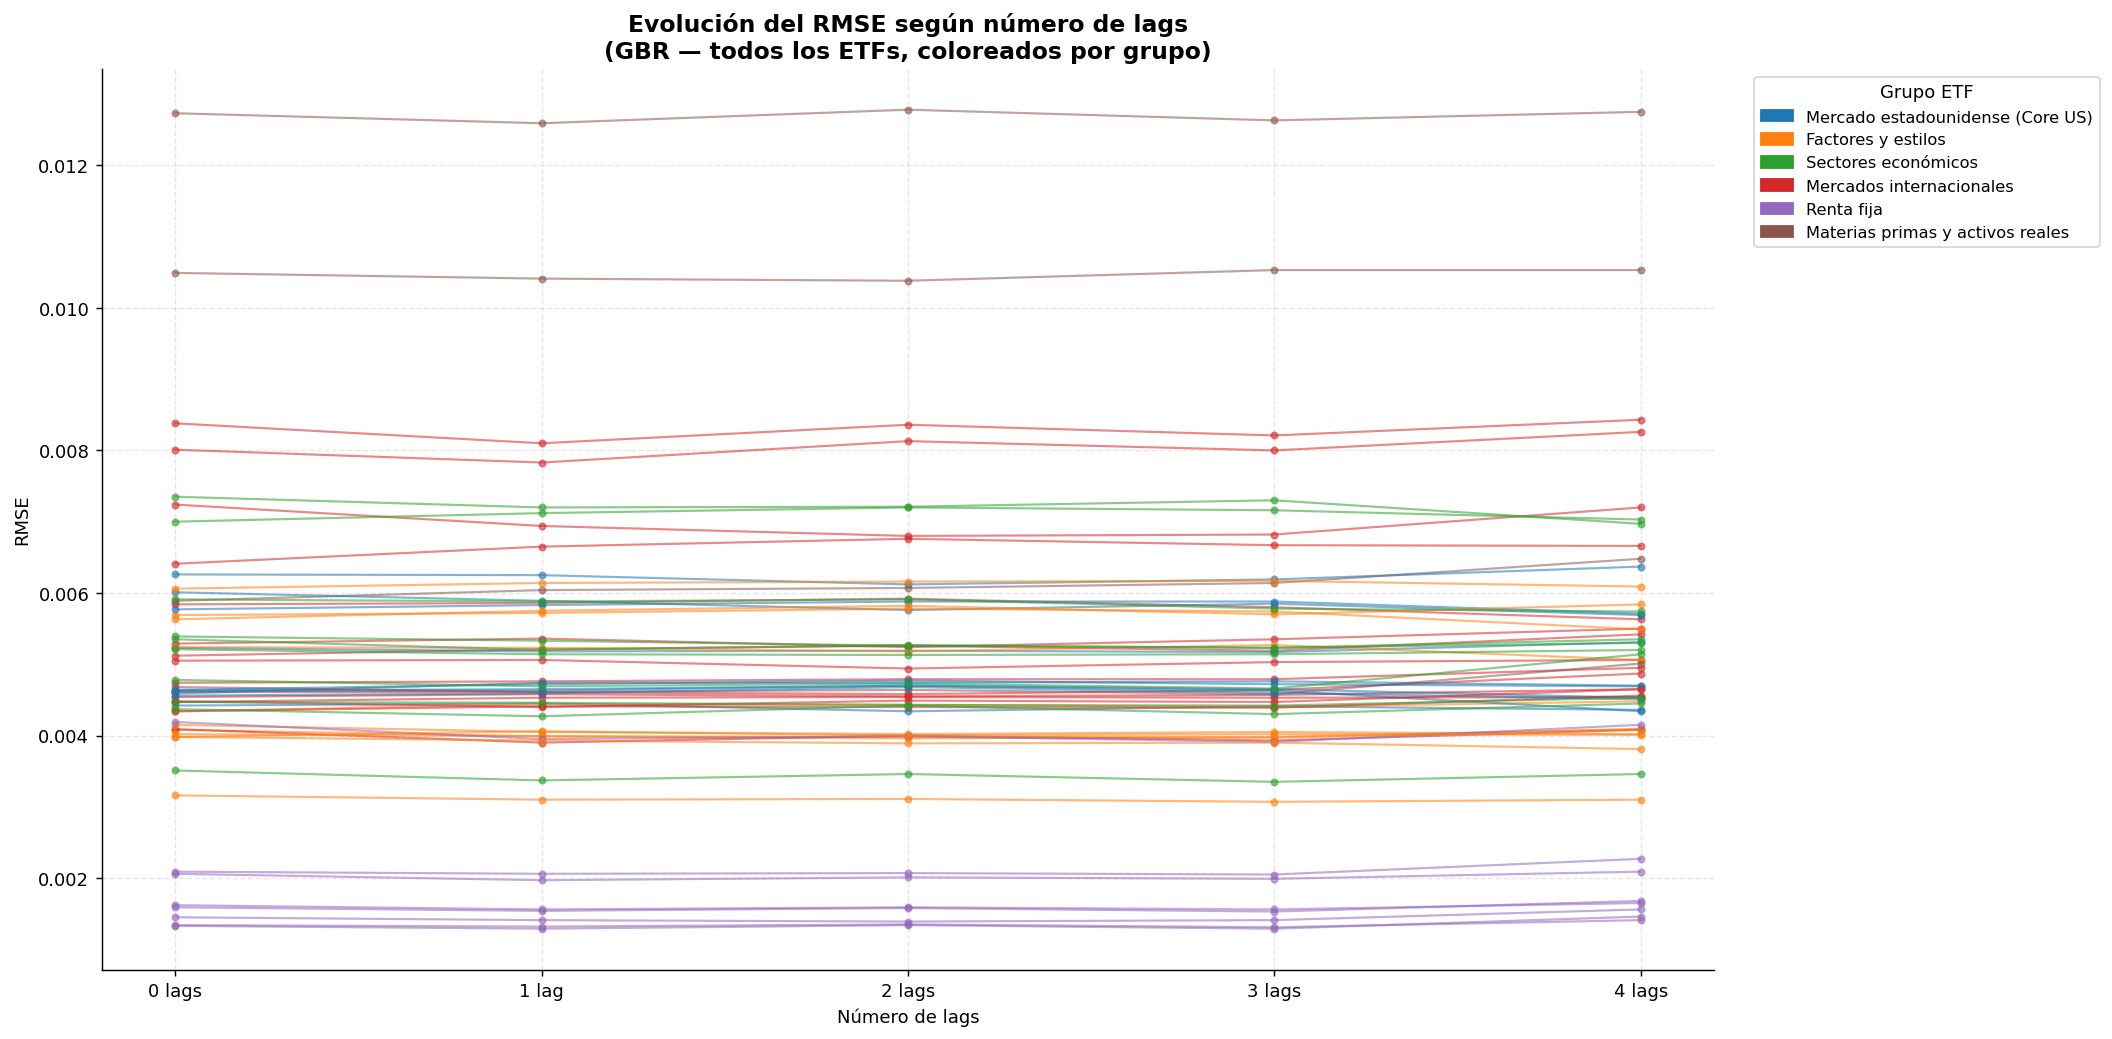

In [134]:

#  Evolución del RMSE según lags, coloreado por grupo
# Un gráfico por método

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# Orden de los archivos / lags
archivos_ord2 = [
    "df_semanal.csv",
    "df_semanal_1.csv",
    "df_semanal_2.csv",
    "df_semanal_3.csv",
    "df_semanal_4.csv"
]

# Colores por grupo
COLORES_GRUPO = {
    "Mercado estadounidense (Core US)": "#1f77b4",
    "Factores y estilos": "#ff7f0e",
    "Sectores económicos": "#2ca02c",
    "Mercados internacionales": "#d62728",
    "Renta fija": "#9467bd",
    "Materias primas y activos reales": "#8c564b",
    "Sin grupo": "#7f7f7f",
}

# Copia para graficar
df_plot = df.copy()

# Asegurar columnas necesarias
df_plot["RMSE"] = pd.to_numeric(df_plot["RMSE"], errors="coerce")
df_plot["Grupo"] = df_plot["ETF"].map(etf_to_grupo).fillna("Sin grupo")

# Si quieres excluir ETFs eliminados también del gráfico:
ETF_ELIMINADOS = {"BIL", "EWY", "GLD", "IAU", "SHY"}
df_plot = df_plot[~df_plot["ETF"].isin(ETF_ELIMINADOS)].copy()


def nombre_corto_metodo(m):
    return (
        m.replace("GradientBoostingRegressor", "GBR")
         .replace("RandomForestRegressor", "RF")
         .replace("LinearRegression", "LR")
    )


def graficar_rmse_lags_todos(df_in, metodo):
    sub_met = df_in[df_in["Método"] == metodo].copy()

    if sub_met.empty:
        print(f"No hay datos para el método: {metodo}")
        return

    etfs_todos = sorted(sub_met["ETF"].dropna().unique())

    fig, ax = plt.subplots(figsize=(16, 9))

    for etf in etfs_todos:
        sub_etf = sub_met[sub_met["ETF"] == etf].copy()
        sub_etf = sub_etf.set_index("Archivo").reindex(archivos_ord2)

        grupo_etf = sub_met.loc[sub_met["ETF"] == etf, "Grupo"].iloc[0]
        color_etf = COLORES_GRUPO.get(grupo_etf, "#888888")

        ax.plot(
            [LAGS_LABEL.get(a, a) for a in archivos_ord2],
            sub_etf["RMSE"].values,
            marker="o",
            linestyle="-",
            linewidth=1.2,
            markersize=3.5,
            alpha=0.55,
            color=color_etf
        )

    # Leyenda por grupos
    grupos_presentes = [
        g for g in ORDEN_GRUPOS + ["Sin grupo"]
        if g in sub_met["Grupo"].unique()
    ]

    patches = [
        mpatches.Patch(color=COLORES_GRUPO[g], label=g)
        for g in grupos_presentes
    ]

    ax.legend(
        handles=patches,
        title="Grupo ETF",
        fontsize=9,
        title_fontsize=10,
        loc="upper left",
        bbox_to_anchor=(1.02, 1)
    )

    metodo_txt = nombre_corto_metodo(metodo)

    ax.set_title(
        f"Evolución del RMSE según número de lags\n"
        f"({metodo_txt} — todos los ETFs, coloreados por grupo)",
        fontsize=13,
        fontweight="bold"
    )
    ax.set_xlabel("Número de lags")
    ax.set_ylabel("RMSE")
    ax.grid(True, alpha=0.3)

    # plt.tight_layout()
    # nombre_fig = f"G13_rmse_lags_todos_{metodo_txt}.png"
    # plt.savefig(nombre_fig, dpi=150, bbox_inches="tight")
    # plt.show()

    # print(f"Gráfico guardado: {nombre_fig}")


#
# MÉTODOS A GRAFICAR
#

mejor_metodo_global = df_plot.groupby("Método")["RMSE"].mean().idxmin()

metodos_a_graficar = [
    mejor_metodo_global,
    "Ridge",
    "RandomForestRegressor",
    "GradientBoostingRegressor"
]

# quitar duplicados por si el mejor global ya es Ridge o RF
metodos_a_graficar = list(dict.fromkeys(metodos_a_graficar))

for metodo in metodos_a_graficar:
    graficar_rmse_lags_todos(df_plot, metodo)